# xrt_toolkit tutorial

This notebook exercises the main functionality of the library on small problems:

1. **2D reconstruction** with basis orders 0, 1, 2 (voxels / linear / quadratic box-splines)
2. **3D reconstruction**
3. **Differentiation with respect to the acquisition geometry** (recovering a detector shift by gradient descent)

Each section plots its result next to the ground truth, so a quick visual scan
tells you the library works end to end. A CUDA GPU is required.

Geometries can be given in two ways: the structured helpers `parallel_beam` /
`cone_beam` build standard scans from angles and a `DetectorSpec` (sections 1
and 2), and the explicit interface takes arbitrary per-ray `(t, n)` arrays --
point on the ray and direction -- which is what section 3 uses to move the
detector.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import drjit as dr
from drjit.cuda.ad import Array2f, Float

import xrt_toolkit as xtk

## Helpers

`cg` solves the normal equations $A^\top A f = A^\top y$ with the matched
adjoint; it works with either geometry interface through the `apply`/`adjoint`
pair passed in.

In [2]:
def cg(apply_A, adjoint_A, y, n_unknowns, n_iter=30):
    b = adjoint_A(y)
    f = dr.zeros(Float, n_unknowns)
    r, p = Float(b), Float(b)
    rs = dr.sum(r * r)
    for _ in range(n_iter):
        Ap = adjoint_A(apply_A(p))
        alpha = rs / dr.sum(p * Ap)
        f = dr.fma(alpha, p, f)
        r = dr.fma(-alpha, Ap, r)
        rs_new = dr.sum(r * r)
        p = dr.fma(rs_new / rs, p, r)
        rs = rs_new
        dr.eval(f, r, p, rs)
    return f


def psnr(rec, ref):
    rec, ref = np.asarray(rec), np.asarray(ref)
    return 10 * np.log10(ref.max() ** 2 / np.mean((rec - ref) ** 2))

## 1. 2D reconstruction, orders 0 / 1 / 2

A 128x128 phantom on a lattice centered at the origin, scanned with
`parallel_beam`: 180 angles, 192 detector cells. For each basis order the
phantom is projected and reconstructed with the same order, checking the
forward/adjoint pair end to end; all three should recover the phantom.

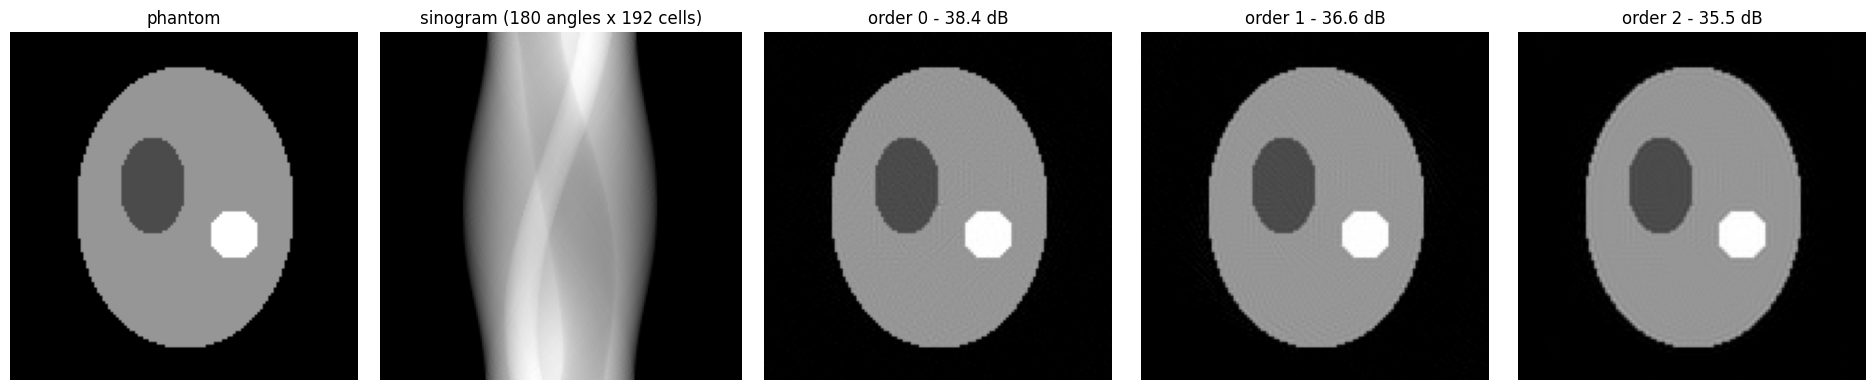

In [3]:
N = 128
yy, xx = np.mgrid[:N, :N]
phantom2d = ((((xx - 64) / 40) ** 2 + ((yy - 64) / 52) ** 2) < 1).astype(np.float32)
phantom2d -= 0.5 * ((((xx - 52) / 12) ** 2 + ((yy - 56) / 18) ** 2) < 1)
phantom2d += 0.7 * ((((xx - 82) / 9) ** 2 + ((yy - 74) / 9) ** 2) < 1)
f_true = Float(phantom2d.reshape(-1))

knot2d = xtk.UniformSpec(start=(-N / 2 + 0.5,) * 2, step=1, num=(N, N))
angles = dr.linspace(Float, 0, np.pi, 180, endpoint=False)
det = xtk.DetectorSpec(size=(1.5 * N,), num_cell=(192,))
rays2d = xtk.parallel_beam(angles, det)

sino0 = xtk.xrt_struct_apply(rays2d, knot2d, 0, f_true)

fig, axs = plt.subplots(1, 5, figsize=(19, 4))
axs[0].imshow(phantom2d, cmap="gray")
axs[0].set_title("phantom")
axs[1].imshow(np.asarray(sino0).reshape(180, 192), cmap="gray", aspect="auto")
axs[1].set_title("sinogram (180 angles x 192 cells)")
for ax, order in zip(axs[2:], (0, 1, 2)):
    sino = xtk.xrt_struct_apply(rays2d, knot2d, order, f_true)
    rec = cg(lambda v: xtk.xrt_struct_apply(rays2d, knot2d, order, v),
             lambda v: xtk.xrt_struct_adjoint(rays2d, knot2d, order, v),
             sino, N * N)
    rec = np.asarray(rec).reshape(N, N)
    ax.imshow(rec, cmap="gray", vmin=phantom2d.min(), vmax=phantom2d.max())
    ax.set_title(f"order {order} - {psnr(rec, phantom2d):.1f} dB")
for ax in axs:
    ax.axis("off")
plt.tight_layout()

## 2. 3D reconstruction

The same helper builds 3D scans when the detector is two-dimensional: a
32x32x32 phantom of three spheres, 60 angles, 48x48 detector.

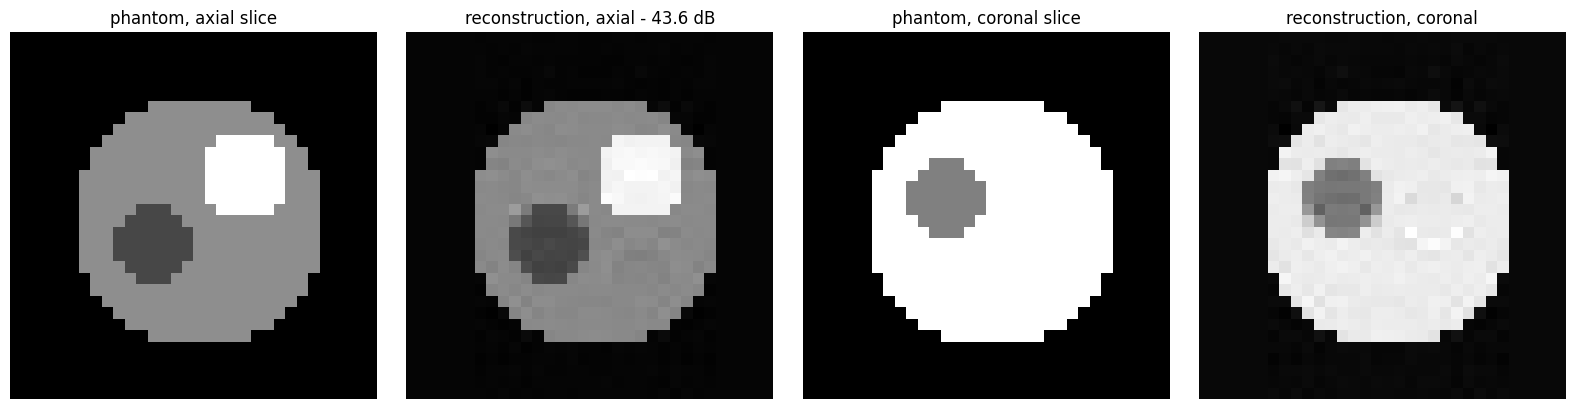

In [4]:
N3 = 32
zz, yy, xx = np.mgrid[:N3, :N3, :N3]
phantom3d = ((xx - 16) ** 2 + (yy - 16) ** 2 + (zz - 16) ** 2 < 11 ** 2).astype(np.float32)
phantom3d += 0.8 * ((xx - 20) ** 2 + (yy - 12) ** 2 + (zz - 16) ** 2 < 4 ** 2)
phantom3d -= 0.5 * ((xx - 12) ** 2 + (yy - 18) ** 2 + (zz - 14) ** 2 < 4 ** 2)

knot3d = xtk.UniformSpec(start=(-N3 / 2 + 0.5,) * 3, step=1, num=(N3,) * 3)
angles3 = dr.linspace(Float, 0, np.pi, 60, endpoint=False)
det3 = xtk.DetectorSpec(size=(1.5 * N3, 1.5 * N3), num_cell=(48, 48))
rays3d = xtk.parallel_beam(angles3, det3)

sino3d = xtk.xrt_struct_apply(rays3d, knot3d, 0, Float(phantom3d.reshape(-1)))
rec3d = cg(lambda v: xtk.xrt_struct_apply(rays3d, knot3d, 0, v),
           lambda v: xtk.xrt_struct_adjoint(rays3d, knot3d, 0, v),
           sino3d, N3 ** 3)
rec3d = np.asarray(rec3d).reshape(N3, N3, N3)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(phantom3d[16], cmap="gray")
axs[0].set_title("phantom, axial slice")
axs[1].imshow(rec3d[16], cmap="gray")
axs[1].set_title(f"reconstruction, axial - {psnr(rec3d, phantom3d):.1f} dB")
axs[2].imshow(phantom3d[:, 16], cmap="gray")
axs[2].set_title("phantom, coronal slice")
axs[3].imshow(rec3d[:, 16], cmap="gray")
axs[3].set_title("reconstruction, coronal")
for ax in axs:
    ax.axis("off")
plt.tight_layout()

## 3. Differentiating through the geometry

The projection is differentiable with respect to the ray parameters
(`xrt_ad_t_*` for the ray origins, `xrt_ad_n_*` for the directions). These
functions take the explicit `(t, n)` interface, which can express what a
structured scan cannot -- here, a detector shifted by 1.5 lattice units along
its own axis. Treating the shift as an unknown and following the gradient of
the data misfit recovers it.

recovered shift: 1.5000  (true 1.5)


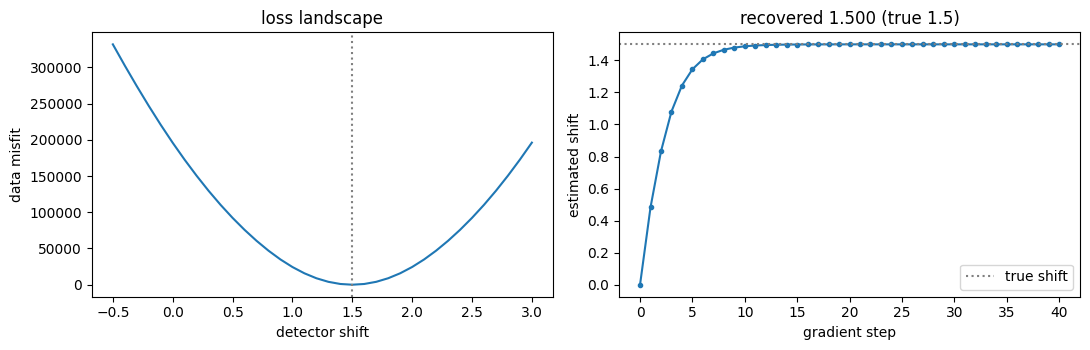

In [5]:
a = np.linspace(0, np.pi, 180, endpoint=False)
u = np.linspace(-0.75 * N, 0.75 * N, 192)
ca, sa = np.cos(a), np.sin(a)
# beam direction (cos a, sin a); detector axis (-sin a, cos a); rays through
# the detector cells, volume centered at the origin (same scan as section 1)
t0 = np.stack([-u[None] * sa[:, None], u[None] * ca[:, None]], 0).reshape(2, -1)
n0 = np.stack([np.broadcast_to(ca[:, None], (180, 192)),
               np.broadcast_to(sa[:, None], (180, 192))], 0).reshape(2, -1)
ux, uy = -n0[1], n0[0]                      # per-ray detector axis

def shifted_rays(s):
    return (Array2f(t0[0] + s * ux, t0[1] + s * uy), Array2f(n0))

shift_true = 1.5
y_meas = xtk.xrt_apply(shifted_rays(shift_true), knot2d, 1, f_true)

def loss_and_grad(s):
    rays = shifted_rays(s)
    resid = xtk.xrt_apply(rays, knot2d, 1, f_true) - y_meas
    gx = xtk.xrt_ad_t_x(rays, knot2d, 1, f_true)
    gy = xtk.xrt_ad_t_y(rays, knot2d, 1, f_true)
    g = dr.sum(resid * (Float(ux) * gx + Float(uy) * gy))
    return 0.5 * float(dr.sum(resid * resid).item()), float(g.item())

s, lr = 0.0, 2e-6
path = [s]
for it in range(40):
    L, g = loss_and_grad(s)
    s -= lr * g
    path.append(s)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
ss = np.linspace(-0.5, 3.0, 36)
axs[0].plot(ss, [loss_and_grad(v)[0] for v in ss], "-")
axs[0].axvline(shift_true, color="gray", ls=":")
axs[0].set_xlabel("detector shift"); axs[0].set_ylabel("data misfit")
axs[0].set_title("loss landscape")
axs[1].plot(path, "o-", ms=3)
axs[1].axhline(shift_true, color="gray", ls=":", label="true shift")
axs[1].set_xlabel("gradient step"); axs[1].set_ylabel("estimated shift")
axs[1].set_title(f"recovered {path[-1]:.3f} (true {shift_true})")
axs[1].legend()
plt.tight_layout()
print(f"recovered shift: {path[-1]:.4f}  (true {shift_true})")